# Spectral Graph & Extended Cluster Features — Combined Dataset

This notebook applies two novel feature groups to the **combined
2 500-question dataset**, alongside our 7 baseline geometric features.
Total feature space: **16 features** (7 baseline + 6 spectral + 3 extended cluster).

Pipeline: feature computation → EDA → KS tests → permutation tests →
bootstrap CI → ablation → significant-feature ablation → SHAP.

---

## Complete Feature Inventory

### Baseline (7 features — our pipeline)

| # | Symbol | Formula | Reference |
|---|--------|---------|----------|
| 1 | $H_{\text{sem}}$ | $-\sum_k p_k \log_2 p_k$ | Farquhar et al. (2024) |
| 2 | $D_{\cos}$ | $\frac{1}{N}\sum_j(1-\cos(\mathbf{e}_j,\bar{\mathbf{e}}))$ | Ricco et al. (2025) |
| 3 | $D_{\cos,\text{var}}$ | $\text{Var}_j[1-\cos(\mathbf{e}_j,\bar{\mathbf{e}})]$ |  |
| 4 | $D_{\text{pair}}$ | $\frac{1}{\binom{N}{2}}\sum_{j<k}(1-S_{jk})$ |  |
| 5 | $\bar{M}$ | $\frac{1}{N}\sum_j\sqrt{(\mathbf{e}_j-\mu)^\top\Sigma^{-1}(\mathbf{e}_j-\mu)}$ | Lee et al. (2018) |
| 6 | $K$ | number of agglomerative clusters | — |
| 7 | $\sigma^2_S$ | $\text{Var}\{S_{jk}:j<k\}$ | — |

### Group A — Spectral Graph (6 features)

Graph Laplacian: $\mathbf{L}=\mathbf{D}-\mathbf{W}$, $W_{jk}=\max(S_{jk},0)$, $W_{jj}=0$, $D_{ii}=\sum_j W_{ij}$

Eigendecomposition: $0=\lambda_1\le\lambda_2\le\cdots\le\lambda_N$, eigenvectors $\mathbf{v}_1,\mathbf{v}_2,\ldots$

| # | Symbol | Formula | Interpretation |
|---|--------|---------|----------------|
| 10 | $\lambda_2$ | 2nd eigenvalue of $\mathbf{L}$ | **Fiedler value** — algebraic connectivity; low = responses diverge |
| 11 | $\lambda_3$ | 3rd eigenvalue | Together with $\lambda_2$ captures tri-partition geometry |
| 12 | SGR | $\lambda_2/(\lambda_3+\varepsilon)$ | **Spectral Gap Ratio** — clean bipartition signal |
| 13 | $H_{\text{spec}}$ | $-\sum_i q_i\log_2 q_i,\;q_i=\lambda_i/\sum_i\lambda_i$ | **Spectral Entropy** — eigenvalue spread complexity |
| 14 | IPR | $\sum_j v_2[j]^4$ | **Inverse Participation Ratio** — Fiedler vector localisation |
| 15 | HFER | $\lambda_2\times H_{\text{Fiedler}}$ | Connectivity × partition geometry |

### Group B — Extended Cluster Structure (3 features)

Cluster proportions $p_1\ge p_2\ge\cdots\ge p_K$ from agglomerative clustering.

| # | Symbol | Formula | Interpretation |
|---|--------|---------|----------------|
| 16 | $p_1$ | $\max_k p_k$ | Largest cluster fraction — model confidence |
| 17 | $p_2$ | 2nd-largest $p_k$ | Runner-up fraction — competing answer strength |
| 18 | singleton\_frac | (# singletons)$/N$ | Incoherence signal — isolated divergent responses |

---

## Explanation for the Permutation Tests on $\lambda_2$ and `singleton_cluster_frac`

The permutation test answers a targeted question: *does this specific feature
have a significantly different mean between hallucinated and correct questions?*
We pick the two features with the clearest theoretical prediction:

**$\lambda_2$ (Fiedler value):**
A confident model produces responses that all say the same thing —
the response graph is tightly connected, so $\lambda_2$ is large.
A hallucinating model produces responses that contradict each other —
the graph weakens or splits, so $\lambda_2$ is small.
The theoretical prediction is unambiguous and directional:
$\lambda_2^{\text{correct}} > \lambda_2^{\text{hallucinated}}$.
This makes it the natural candidate for a one-sided permutation test.

**`singleton_cluster_frac`:**
A singleton is a response so divergent from all others that agglomerative
clustering places it alone in its own cluster.
A hallucinating model is more likely to produce a completely different
fabricated answer — so singleton fraction should be higher for hallucinated questions.
This prediction is also directional:
$\text{singleton\_frac}^{\text{hallucinated}} > \text{singleton\_frac}^{\text{correct}}$.

The KS test checks the full distribution for all 9 new features.
The permutation test is reserved for these two because they have the
clearest prior theoretical expectation — making the result confirmatory
rather than a post-hoc correlation search.

---

## Setup

In [1]:
import sys, os
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
import copy

from spectral_detection.data.cleaning import (
    load_dataset, add_canonical_domain, GEO_FEATURES, FEAT_NICE_NAMES,
)
from spectral_detection.feature_extraction import (
    extract_spectral_features,
    SPECTRAL_FEATURES, EXTENDED_CLUSTER_FEATURES,
    ALL_NEW_FEATURES, ALL_NEW_NICE_NAMES,
    SPECTRAL_NICE_NAMES, EXTENDED_CLUSTER_NICE_NAMES,
)
from spectral_detection.analysis.stats import (
    run_global_ks_tests, run_permutation_test, run_bootstrap_auc,
)
from spectral_detection.visualization import (
    plot_feature_distributions, plot_correlation_matrix,
    plot_permutation_test, plot_bootstrap_auc,
    plot_ablation_bar, plot_roc_curves, plot_ablation_roc_curves,
    plot_shap_beeswarm,
)
from spectral_detection.training import build_classifiers

sns.set_style('whitegrid')
ALL_FEATURES = GEO_FEATURES + ALL_NEW_FEATURES   # 7 + 9 = 16
ALL_NICE     = {**FEAT_NICE_NAMES, **ALL_NEW_NICE_NAMES}
print(f'Total features: {len(ALL_FEATURES)}')
for i, f in enumerate(ALL_FEATURES):
    print(f'  [{i:02d}] {f:35s} {ALL_NICE[f]}')


Total features: 16
  [00] H_sem                               Semantic Entropy
  [01] D_cos                               Cosine Dispersion (mean centroid)
  [02] D_cos_var                           Cosine Dispersion (variance centroid)
  [03] D_pair                              Mean Pairwise Cosine Distance
  [04] M_bar                               Mahalanobis Distance (mean)
  [05] K                                   Cluster Count
  [06] sig2_S                              Similarity Variance
  [07] lam2                                Fiedler Value (λ₂)
  [08] lam3                                Third Eigenvalue (λ₃)
  [09] SGR                                 Spectral Gap Ratio (λ₂/λ₃)
  [10] spectral_entropy                    Spectral Entropy
  [11] ipr_fiedler                         IPR Fiedler Vector
  [12] HFER                                HFER (λ₂ × Fiedler Entropy)
  [13] largest_cluster_frac                Largest Cluster Fraction
  [14] second_largest_cluster_frac       

## Configuration

In [4]:
DATA_DIR   = '../data/processed'
NPY_DIR    = '../data/temp/pny/'
CSV_DIR    = '../data/temp/processed_csv/'
OUTPUT_DIR = '../data/processed/temp/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

SIM_THRESHOLD  = 0.85
N_PERMUTATIONS = 10_000
N_BOOTSTRAP    = 2_000
RANDOM_SEED    = 42
np.random.seed(RANDOM_SEED)

DATASET_FILES = {
    'defan':      'defan_t0.9_n20.jsonl',
    'halueval':   'halueval_t1.0_n20.jsonl',
    'mmlu':       'mmlu_t1.0_n20.jsonl',
    'triviaqa':   'triviaqa_t1.0_n20.jsonl',
    'truthfulqa': 'truthfulqa_t1.0_n20.jsonl',
}


---
## Load Combined Data & Compute Spectral Features


In [5]:
dfs, embs_list = [], []
for ds_name, fname in DATASET_FILES.items():
    _df = load_dataset(os.path.join(DATA_DIR, fname))
    if ds_name != 'defan':
        _df = add_canonical_domain(_df)
    dfs.append(_df)
    embs_list.append(np.load(os.path.join(NPY_DIR, f'{ds_name}_embeddings.npy')))
    print(f'{ds_name}: {len(_df):,} responses')

df_combined  = pd.concat(dfs, ignore_index=True)
emb_combined = np.vstack(embs_list)
print(f'\nCombined: {len(df_combined):,} responses  {emb_combined.shape}')


defan: 10,000 responses
halueval: 10,000 responses
mmlu: 10,000 responses
triviaqa: 10,000 responses
truthfulqa: 10,000 responses

Combined: 50,000 responses  (50000, 384)


In [6]:
# Load our baseline 9-feature DataFrame (computed in feature_extraction.ipynb)
feat_base = pd.read_csv(os.path.join(CSV_DIR, 'combined_features.csv'))
feat_base = feat_base.set_index('prompt_id')
print(f'Baseline features: {feat_base.shape}  — columns: {GEO_FEATURES}')


Baseline features: (2500, 31)  — columns: ['H_sem', 'D_cos', 'D_cos_var', 'D_pair', 'M_bar', 'K', 'sig2_S']


In [7]:
# Compute spectral + extended cluster features
feat_spectral = extract_spectral_features(
    df_combined, emb_combined,
    sim_threshold=SIM_THRESHOLD, verbose=True,
)
# Merge
feat_df = feat_base.join(feat_spectral[ALL_NEW_FEATURES], how='inner').reset_index()
print(f'\nFull feature matrix: {feat_df.shape}')
print(f'Label: {feat_df["label"].value_counts().to_dict()}')
feat_df.to_csv(os.path.join(OUTPUT_DIR, 'spectral_features_combined.csv'), index=False)
display(feat_df[ALL_FEATURES].describe().round(4))


Vectorised cosine path: 2500 q × 20 resp
  500/2500 ...
  1000/2500 ...
  1500/2500 ...
  2000/2500 ...
  2500/2500 ...

Spectral features computed for 2500 questions.

Full feature matrix: (2500, 41)
Label: {1: 1394, 0: 1106}


,H_sem,D_cos,D_cos_var,D_pair,M_bar,K,sig2_S,lam2,lam3,SGR,spectral_entropy,ipr_fiedler,HFER,largest_cluster_frac,second_largest_cluster_frac,singleton_cluster_frac
count,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000,2500.0000
mean,2.2504,0.1874,0.0174,0.3371,25.6166,9.1116,0.0412,8.0819,10.0275,0.7683,4.2099,0.5961,27.0917,0.4958,0.1115,0.3529
std,1.5546,0.1394,0.0168,0.2322,11.8085,6.5776,0.0348,6.0345,5.8728,0.2183,0.0382,0.2970,20.7364,0.3406,0.0911,0.3275
min,-0.0000,-0.0000,0.0000,-0.0000,1.7991,1.0000,0.0000,-0.0000,1.0629,-0.0000,3.9096,0.0500,-0.0000,0.0500,0.0000,0.0000
25%,0.7476,0.0583,0.0042,0.1192,17.3422,3.0000,0.0142,3.0837,4.8233,0.6572,4.1893,0.3214,10.5535,0.1500,0.0500,0.0500
50%,2.4192,0.1805,0.0128,0.3456,21.2176,8.0000,0.0353,5.8702,8.8268,0.8335,4.2191,0.6844,20.0130,0.4500,0.1000,0.2500
75%,3.7842,0.2893,0.0260,0.5210,34.0823,15.0000,0.0596,11.8690,14.5090,0.9342,4.2419,0.8904,38.3157,0.8500,0.1500,0.6500
max,4.3219,0.5781,0.1369,0.8653,67.6068,20.0000,0.2523,20.0000,20.0000,1.0000,4.2479,0.9026,84.6611,1.0000,0.5000,1.0000


---
## EDA


### Feature Distributions by Label


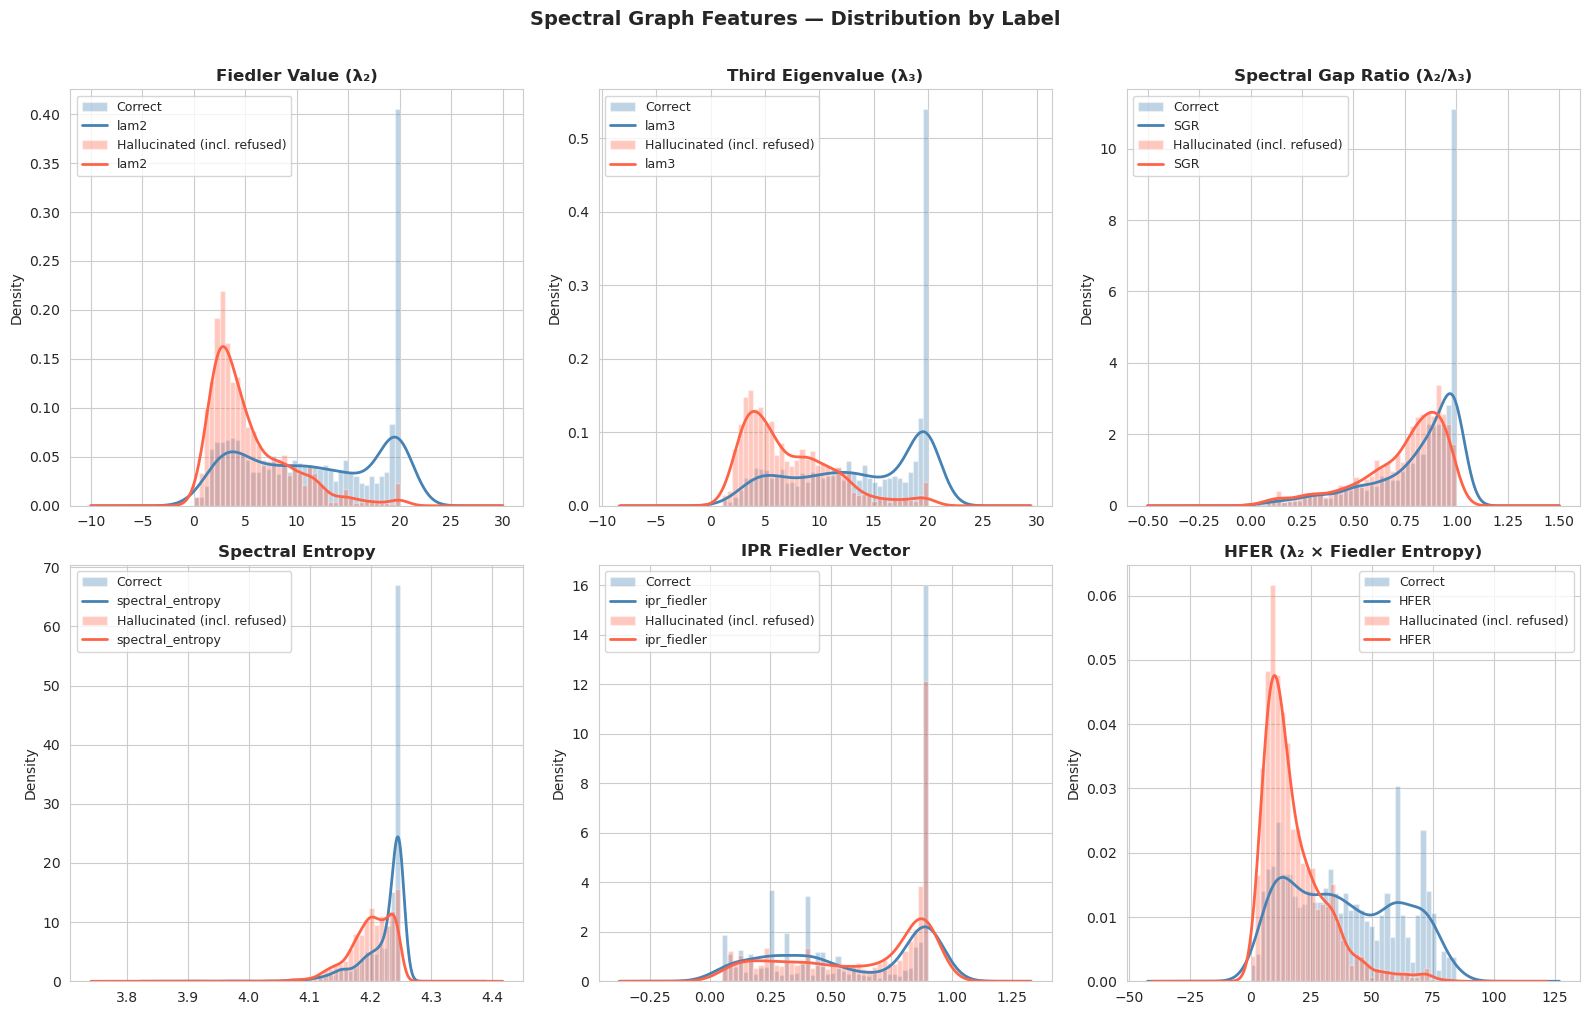

In [8]:
# Spectral features
fig = plot_feature_distributions(
    feat_df, geo_features=SPECTRAL_FEATURES,
    feat_nice=SPECTRAL_NICE_NAMES,
    suptitle='Spectral Graph Features — Distribution by Label',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'spectral_feat_dist.png'), dpi=150, bbox_inches='tight')
plt.show()


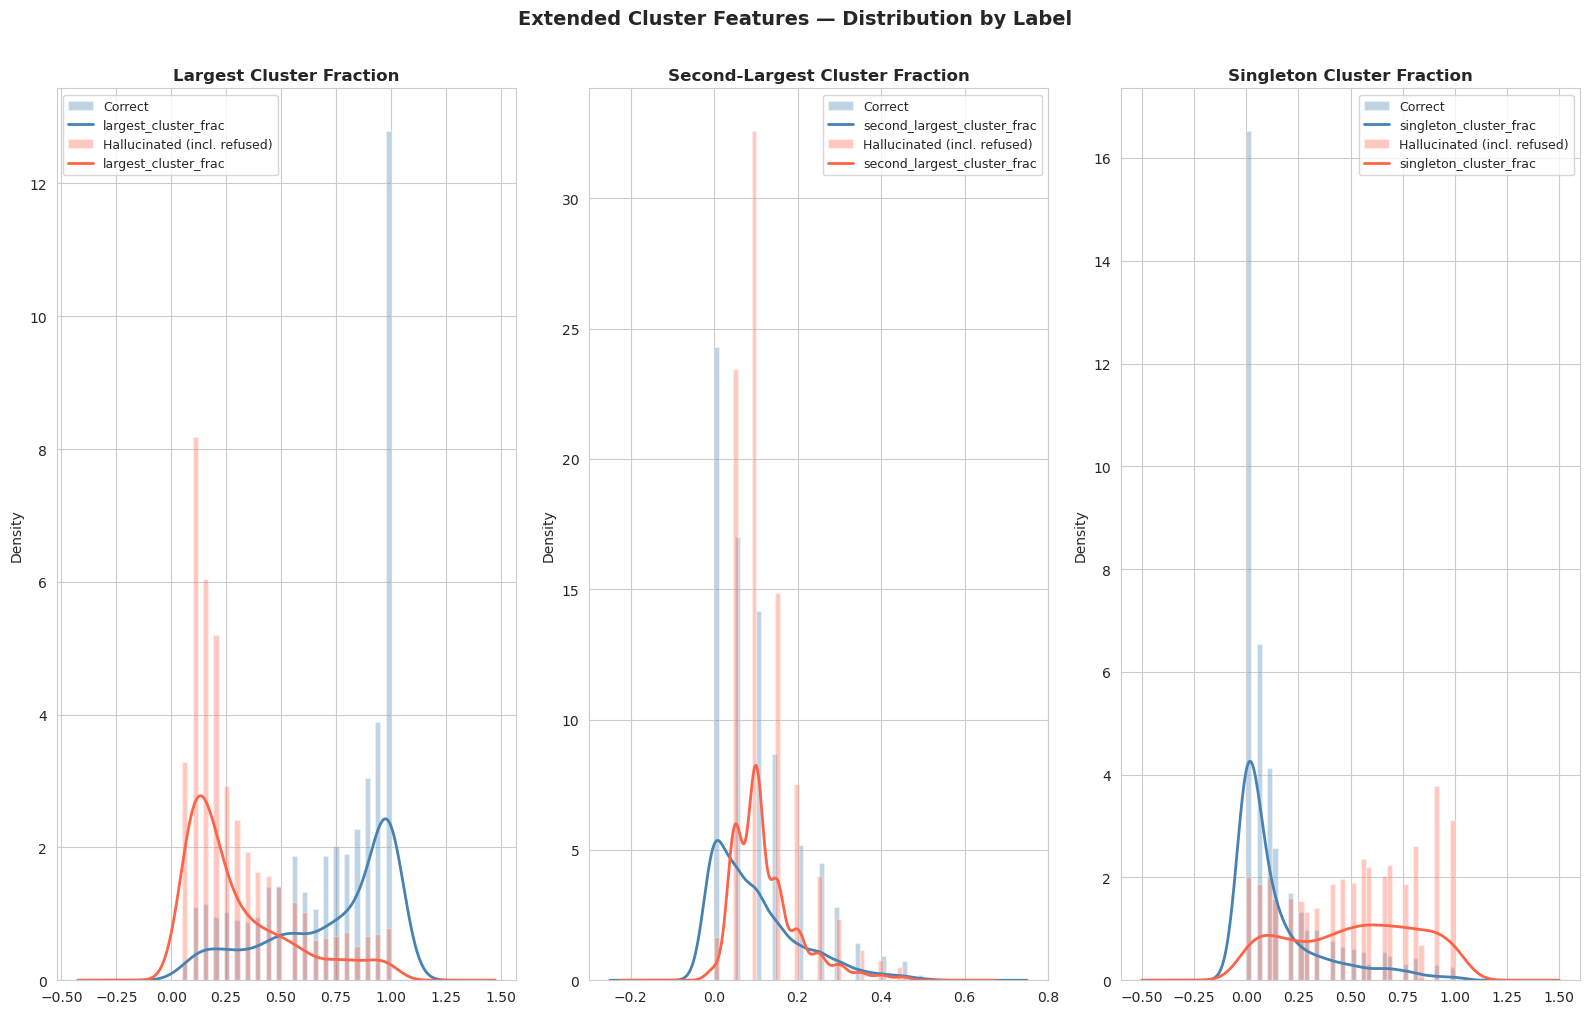

In [9]:
# Extended cluster features
fig = plot_feature_distributions(
    feat_df, geo_features=EXTENDED_CLUSTER_FEATURES,
    feat_nice=EXTENDED_CLUSTER_NICE_NAMES,
    suptitle='Extended Cluster Features — Distribution by Label',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'ext_cluster_feat_dist.png'), dpi=150, bbox_inches='tight')
plt.show()


### Boxplots by Dataset


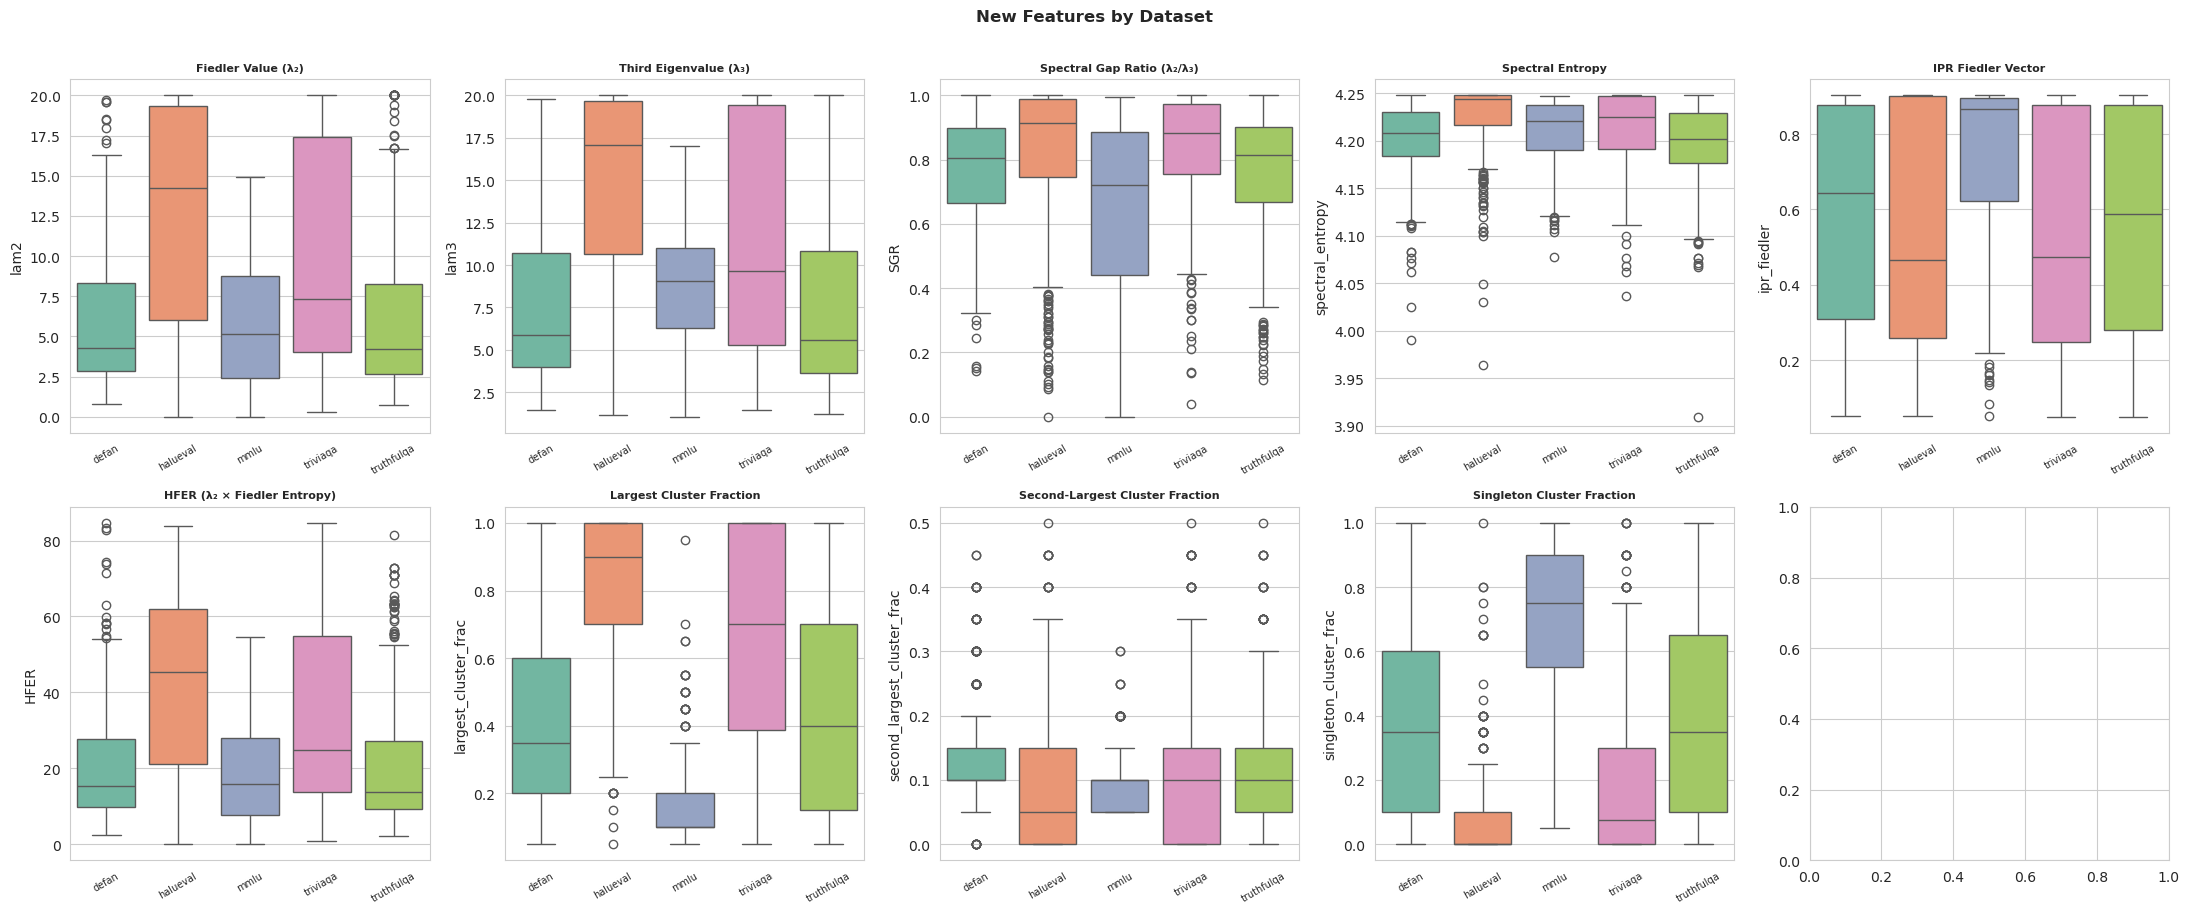

In [10]:
n_feats = len(ALL_NEW_FEATURES)
n_cols, n_rows = 5, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 9))
for ax, feat in zip(axes.flatten(), ALL_NEW_FEATURES):
    sns.boxplot(data=feat_df, x='dataset', y=feat, ax=ax,
                palette='Set2', order=sorted(feat_df['dataset'].unique()))
    ax.set_title(ALL_NICE.get(feat, feat), fontweight='bold', fontsize=8)
    ax.set_xlabel(''); ax.tick_params(axis='x', rotation=30, labelsize=7)
plt.suptitle('New Features by Dataset', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'spectral_boxplots_dataset.png'), dpi=150, bbox_inches='tight')
plt.show()


### Pearson Correlations with Hallucination Label


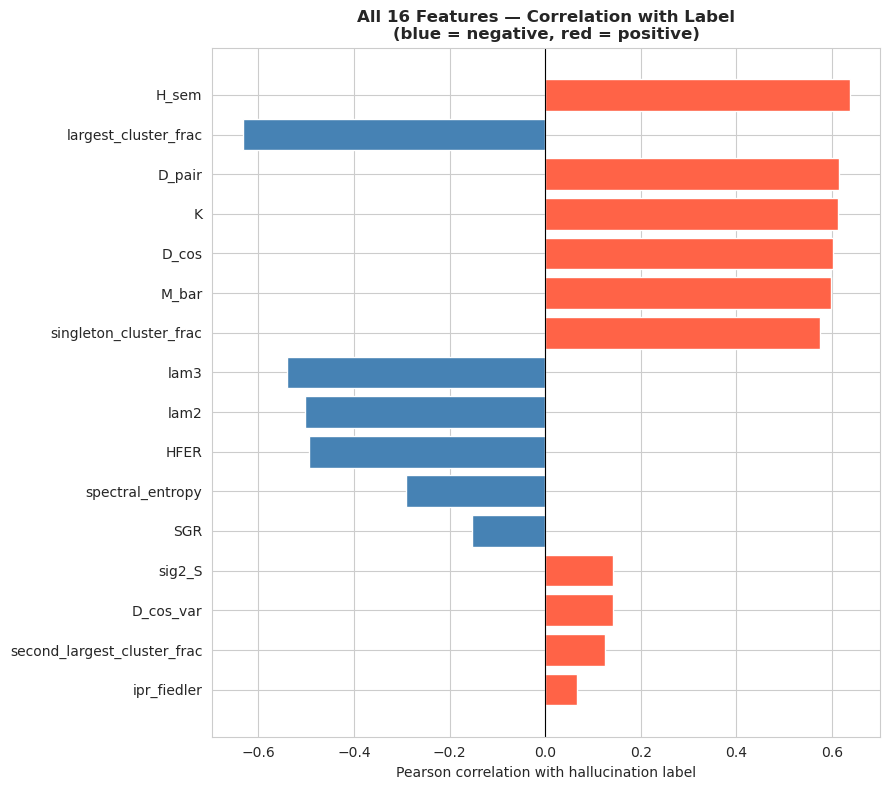

,corr_with_label
H_sem,0.6368
largest_cluster_frac,-0.6330
D_pair,0.6149
K,0.6130
D_cos,0.6030
M_bar,0.5974
singleton_cluster_frac,0.5758
lam3,-0.5396
lam2,-0.5028
HFER,-0.4942


In [25]:
corr_label = (
    feat_df[ALL_FEATURES + ['label']]
    .corr(numeric_only=True)['label']
    .drop('label')
    .sort_values(key=abs, ascending=False)
)
fig, ax = plt.subplots(figsize=(9, 8))
colors = ['tomato' if v > 0 else 'steelblue' for v in corr_label]
ax.barh(corr_label.index[::-1], corr_label.values[::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson correlation with hallucination label')
ax.set_title('All 16 Features — Correlation with Label\n(blue = negative, red = positive)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'spectral_corr_label.png'), dpi=150, bbox_inches='tight')
plt.show()
display(corr_label.to_frame('corr_with_label').round(4))


### Correlation Heatmap — All 16 Features


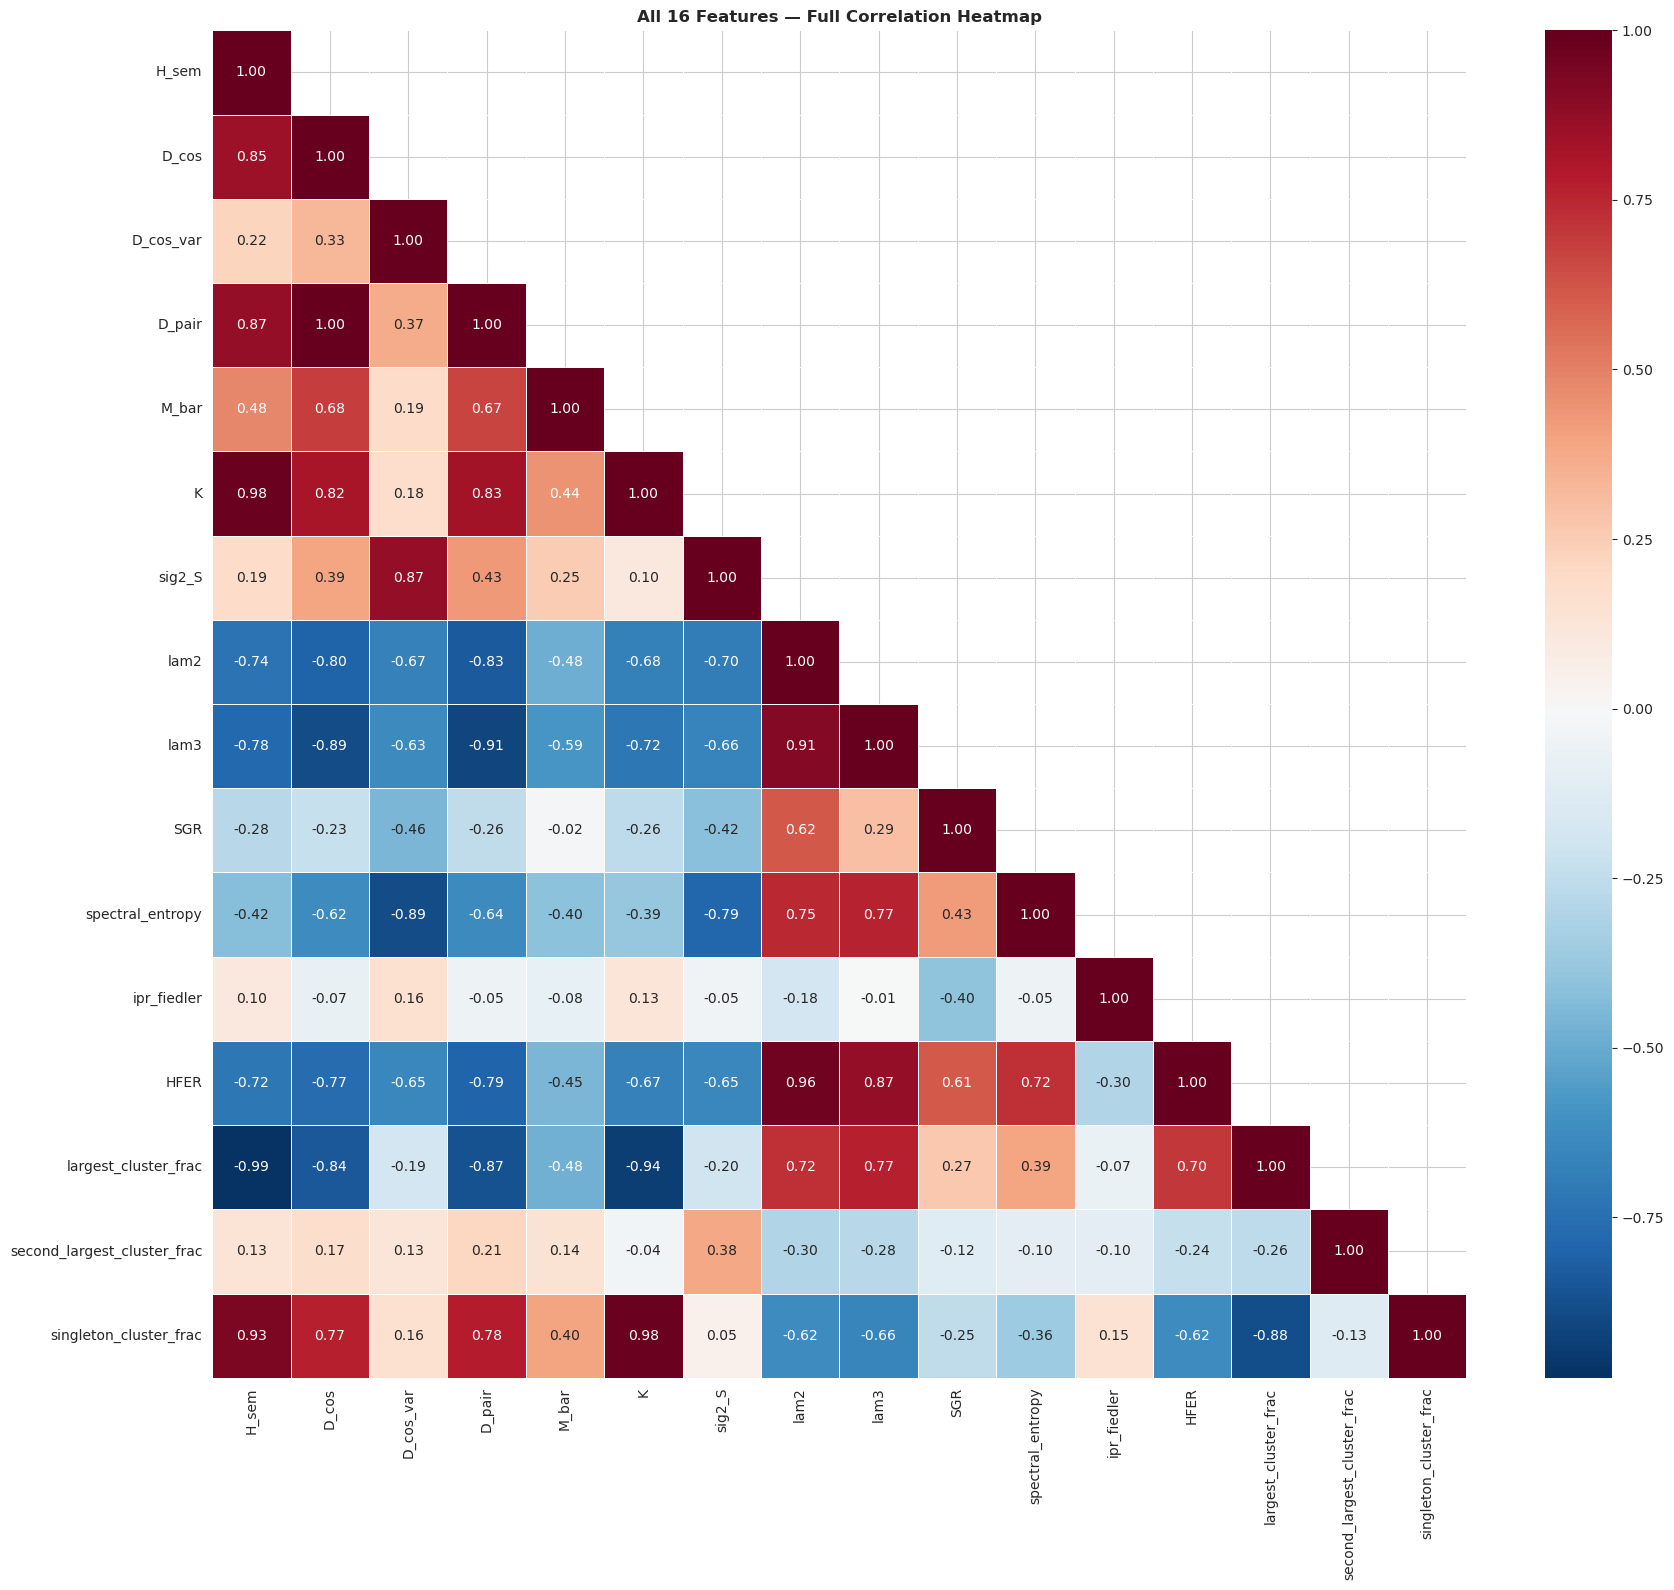

In [26]:
fig = plot_correlation_matrix(
    feat_df, cols=ALL_FEATURES,
    title='All 16 Features — Full Correlation Heatmap',
    figsize=(18, 16),
)
plt.savefig(os.path.join(OUTPUT_DIR, 'spectral_corr_all.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## Statistical Tests


### KS Tests — All New Features

H₀: the feature has the same distribution for hallucinated and correct questions.
Bonferroni correction: α_adj = 0.05 / 10 = 0.005.


Global KS tests  (Bonferroni α = 0.0056, n_tests = 9):
  ✓  lam2          D=0.4297  p=9.45e-103  ***
  ✓  lam3          D=0.4829  p=6.97e-131  ***
  ✓  SGR           D=0.2539  p=1.95e-35  ***
  ✓  spectral_entropy  D=0.3866  p=9.45e-83  ***
  ✓  ipr_fiedler   D=0.1320  p=7.80e-10  ***
  ✓  HFER          D=0.4342  p=5.65e-105  ***
  ✓  largest_cluster_frac  D=0.5834  p=4.92e-195  ***
  ✓  second_largest_cluster_frac  D=0.2851  p=1.10e-44  ***
  ✓  singleton_cluster_frac  D=0.5599  p=1.13e-178  ***


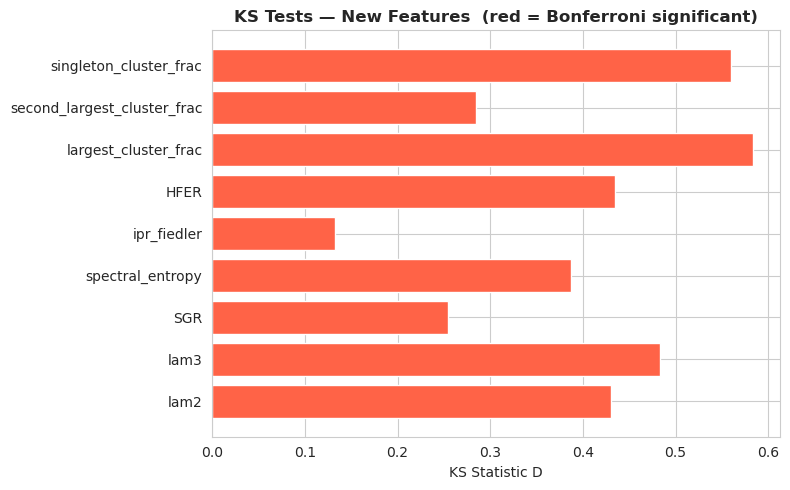

,Feature,KS_stat,p_value,sig,Significant
0,lam2,0.4297,9.452354e-103,***,True
1,lam3,0.4829,6.972002e-131,***,True
2,SGR,0.2539,1.951618e-35,***,True
3,spectral_entropy,0.3866,9.446141e-83,***,True
4,ipr_fiedler,0.1320,7.801238e-10,***,True
5,HFER,0.4342,5.648685e-105,***,True
6,largest_cluster_frac,0.5834,4.922711e-195,***,True
7,second_largest_cluster_frac,0.2851,1.103122e-44,***,True
8,singleton_cluster_frac,0.5599,1.129557e-178,***,True


In [13]:
df_ks = run_global_ks_tests(
    feat_df, geo_features=ALL_NEW_FEATURES, alpha=0.05, verbose=True,
)
df_ks.to_csv(os.path.join(OUTPUT_DIR, 'spectral_ks_tests.csv'), index=False)

fig, ax = plt.subplots(figsize=(8, 5))
colors_ks = ['tomato' if s else 'steelblue' for s in df_ks['Significant']]
ax.barh(df_ks['Feature'], df_ks['KS_stat'], color=colors_ks)
ax.set_xlabel('KS Statistic D')
ax.set_title('KS Tests — New Features  (red = Bonferroni significant)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'spectral_ks_bar.png'), dpi=150, bbox_inches='tight')
plt.show()
display(df_ks)


### Permutation Test — Fiedler Value λ₂

H₀: mean(λ₂ | y=0) = mean(λ₂ | y=1).
We sign-flip λ₂ so that 'higher = worse' (hallucinated), matching
the convention of the other tests. See the header for the theoretical
justification for choosing this feature.


Permutation test (10000 iterations):
  Observed Δ = 6.1074 bits
  p-value    = 0.000000


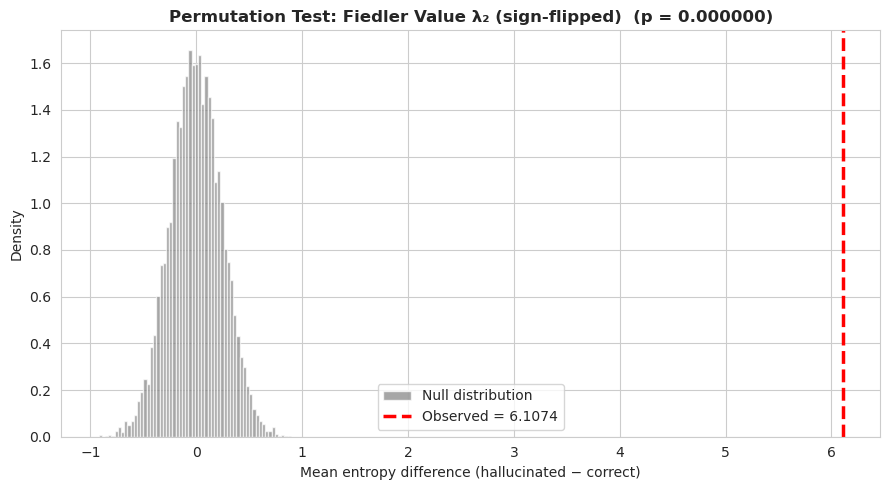

In [14]:
feat_df['lam2_neg'] = -feat_df['lam2']
delta_lam2, perm_d_lam2, pval_lam2 = run_permutation_test(
    feat_df, n_permutations=N_PERMUTATIONS,
    entropy_col='lam2_neg', random_seed=RANDOM_SEED,
)
fig = plot_permutation_test(
    perm_d_lam2, delta_lam2, N_PERMUTATIONS, pval_lam2,
    title='Permutation Test: Fiedler Value λ₂ (sign-flipped)',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'spectral_perm_lam2.png'), dpi=150, bbox_inches='tight')
plt.show()


### Permutation Test — Singleton Cluster Fraction

H₀: mean(singleton_frac | y=1) = mean(singleton_frac | y=0).
See header for justification.


Permutation test (10000 iterations):
  Observed Δ = 0.3796 bits
  p-value    = 0.000000


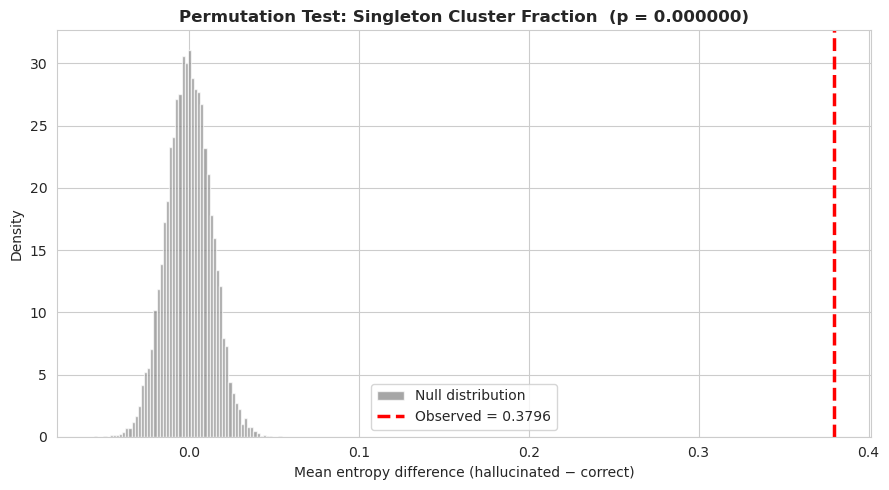

In [15]:
delta_sing, perm_d_sing, pval_sing = run_permutation_test(
    feat_df, n_permutations=N_PERMUTATIONS,
    entropy_col='singleton_cluster_frac', random_seed=RANDOM_SEED,
)
fig = plot_permutation_test(
    perm_d_sing, delta_sing, N_PERMUTATIONS, pval_sing,
    title='Permutation Test: Singleton Cluster Fraction',
)
plt.savefig(os.path.join(OUTPUT_DIR, 'spectral_perm_singleton.png'), dpi=150, bbox_inches='tight')
plt.show()



### Bootstrap CI on AUC-ROC

We run bootstrap (B=2000, OOB evaluation) for three feature sets:
spectral-only (6 features), all 9 new features, and the full 16-feature set.

In [16]:
X_sc_all = StandardScaler().fit_transform(feat_df[ALL_FEATURES].values)
y_all    = feat_df['label'].values
feat_to_idx = {f: i for i, f in enumerate(ALL_FEATURES)}

boot_results = {}
for label, feats in [
    ('Spectral graph only (6)', SPECTRAL_FEATURES),
    ('All 9 new features',     ALL_NEW_FEATURES),
    ('Full 16 features',        ALL_FEATURES),
]:
    boot, lo, hi = run_bootstrap_auc(
        feat_df, geo_features=feats,
        n_bootstrap=N_BOOTSTRAP, random_seed=RANDOM_SEED, verbose=False,
    )
    boot_results[label] = (boot, lo, hi)
    print(f'{label:40s}  AUC={boot.mean():.4f}  95% CI [{lo:.4f}, {hi:.4f}]')


Spectral graph only (6)                   AUC=0.8282  95% CI [0.8061, 0.8505]


KeyboardInterrupt: 

In [ ]:
# Side-by-side bootstrap distribution plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (lbl, (boot, lo, hi)) in zip(axes, boot_results.items()):
    ax.hist(boot, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(boot.mean(), color='navy', lw=2, label=f'Mean={boot.mean():.4f}')
    ax.axvline(lo, color='red', lw=1.5, linestyle='--')
    ax.axvline(hi, color='red', lw=1.5, linestyle='--',
               label=f'95% CI [{lo:.3f}, {hi:.3f}]')
    ax.axvline(0.5, color='gray', linestyle=':', alpha=0.5, label='Chance')
    ax.set_title(lbl, fontweight='bold', fontsize=9)
    ax.set_xlabel('Bootstrap AUC-ROC')
    ax.legend(fontsize=7)
plt.suptitle('Bootstrap AUC-ROC Distributions', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'spectral_bootstrap_all.png'), dpi=150, bbox_inches='tight')
plt.show()


### Classification & Ablation

Three primary ablation variants — spectral graph only, all 9 new features,
and the full 16-feature pipeline — across all five classifiers.

---
A fourth variant tests only the most significant features identified by KS tests.


In [17]:
classifiers = build_classifiers(RANDOM_SEED)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

# identify KS-significant features
sig_features = df_ks[df_ks['Significant']]['Feature'].tolist()
print('KS-significant features:', sig_features)

# Also add the most correlated from the baseline
corr_top_geo = corr_label[GEO_FEATURES].abs().sort_values(ascending=False)
top_geo = corr_top_geo.head(4).index.tolist()
sig_combined = list(dict.fromkeys(top_geo + sig_features))  
print('Most significant combined:', sig_combined)

ABLATION_SPECTRAL = {
    'Spectral graph only':    SPECTRAL_FEATURES,
    'All 9 new features':    ALL_NEW_FEATURES,
    'Full 16 features':       ALL_FEATURES,
    'Most significant':       sig_combined,
}

abl_rows = []
for variant, feats in ABLATION_SPECTRAL.items():
    idx   = [feat_to_idx[f] for f in feats]
    X_sub = X_sc_all[:, idx]
    for clf_name, clf in classifiers.items():
        scores = cross_val_score(clf, X_sub, y_all, cv=cv, scoring='roc_auc')
        abl_rows.append({
            'Variant': variant, 'Classifier': clf_name,
            'AUC_mean': scores.mean(), 'AUC_std': scores.std(),
        })
        print(f'  {variant:25s} | {clf_name:25s} | {scores.mean():.4f} ± {scores.std():.4f}')

df_abl = pd.DataFrame(abl_rows)
df_abl.to_csv(os.path.join(OUTPUT_DIR, 'spectral_ablation.csv'), index=False)
display(df_abl.pivot_table(index='Variant', columns='Classifier', values='AUC_mean').round(3))


KS-significant features: ['lam2', 'lam3', 'SGR', 'spectral_entropy', 'ipr_fiedler', 'HFER', 'largest_cluster_frac', 'second_largest_cluster_frac', 'singleton_cluster_frac']
Most significant combined: ['H_sem', 'D_pair', 'K', 'D_cos', 'lam2', 'lam3', 'SGR', 'spectral_entropy', 'ipr_fiedler', 'HFER', 'largest_cluster_frac', 'second_largest_cluster_frac', 'singleton_cluster_frac']
  Spectral graph only       | Logistic Regression       | 0.8334 ± 0.0128
  Spectral graph only       | ElasticNet Logit          | 0.8335 ± 0.0127
  Spectral graph only       | Random Forest             | 0.8318 ± 0.0155
  Spectral graph only       | Gradient Boosting         | 0.8349 ± 0.0108
  Spectral graph only       | XGBoost                   | 0.8246 ± 0.0110
  All 9 new features        | Logistic Regression       | 0.8673 ± 0.0127
  All 9 new features        | ElasticNet Logit          | 0.8673 ± 0.0126
  All 9 new features        | Random Forest             | 0.8628 ± 0.0124
  All 9 new features       

Classifier,ElasticNet Logit,Gradient Boosting,Logistic Regression,Random Forest,XGBoost
Variant,,,,,
All 9 new features,0.867,0.852,0.867,0.863,0.842
Full 16 features,0.923,0.946,0.923,0.940,0.944
Most significant,0.875,0.860,0.875,0.869,0.849
Spectral graph only,0.834,0.835,0.833,0.832,0.825


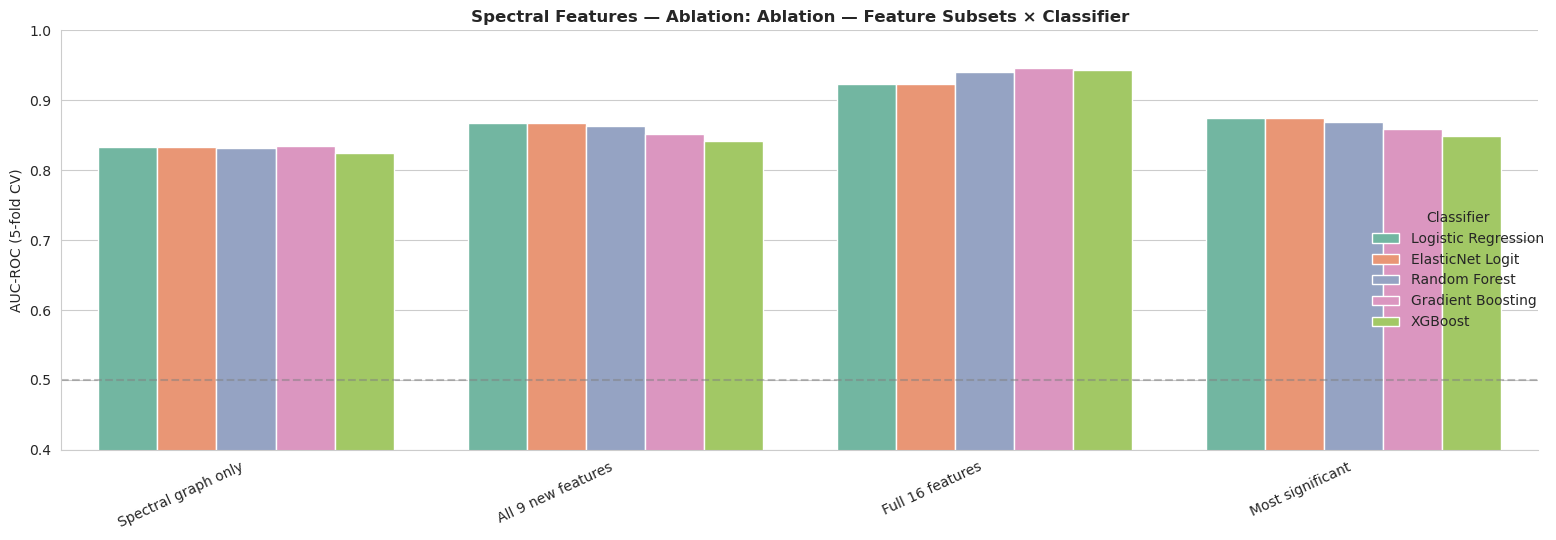

In [18]:
fig = plot_ablation_bar(df_abl, dataset_name='Spectral Features — Ablation')
plt.savefig(os.path.join(OUTPUT_DIR, 'spectral_ablation_bar.png'), dpi=150, bbox_inches='tight')
plt.show()


### Ablation ROC Curves (2-row grid)


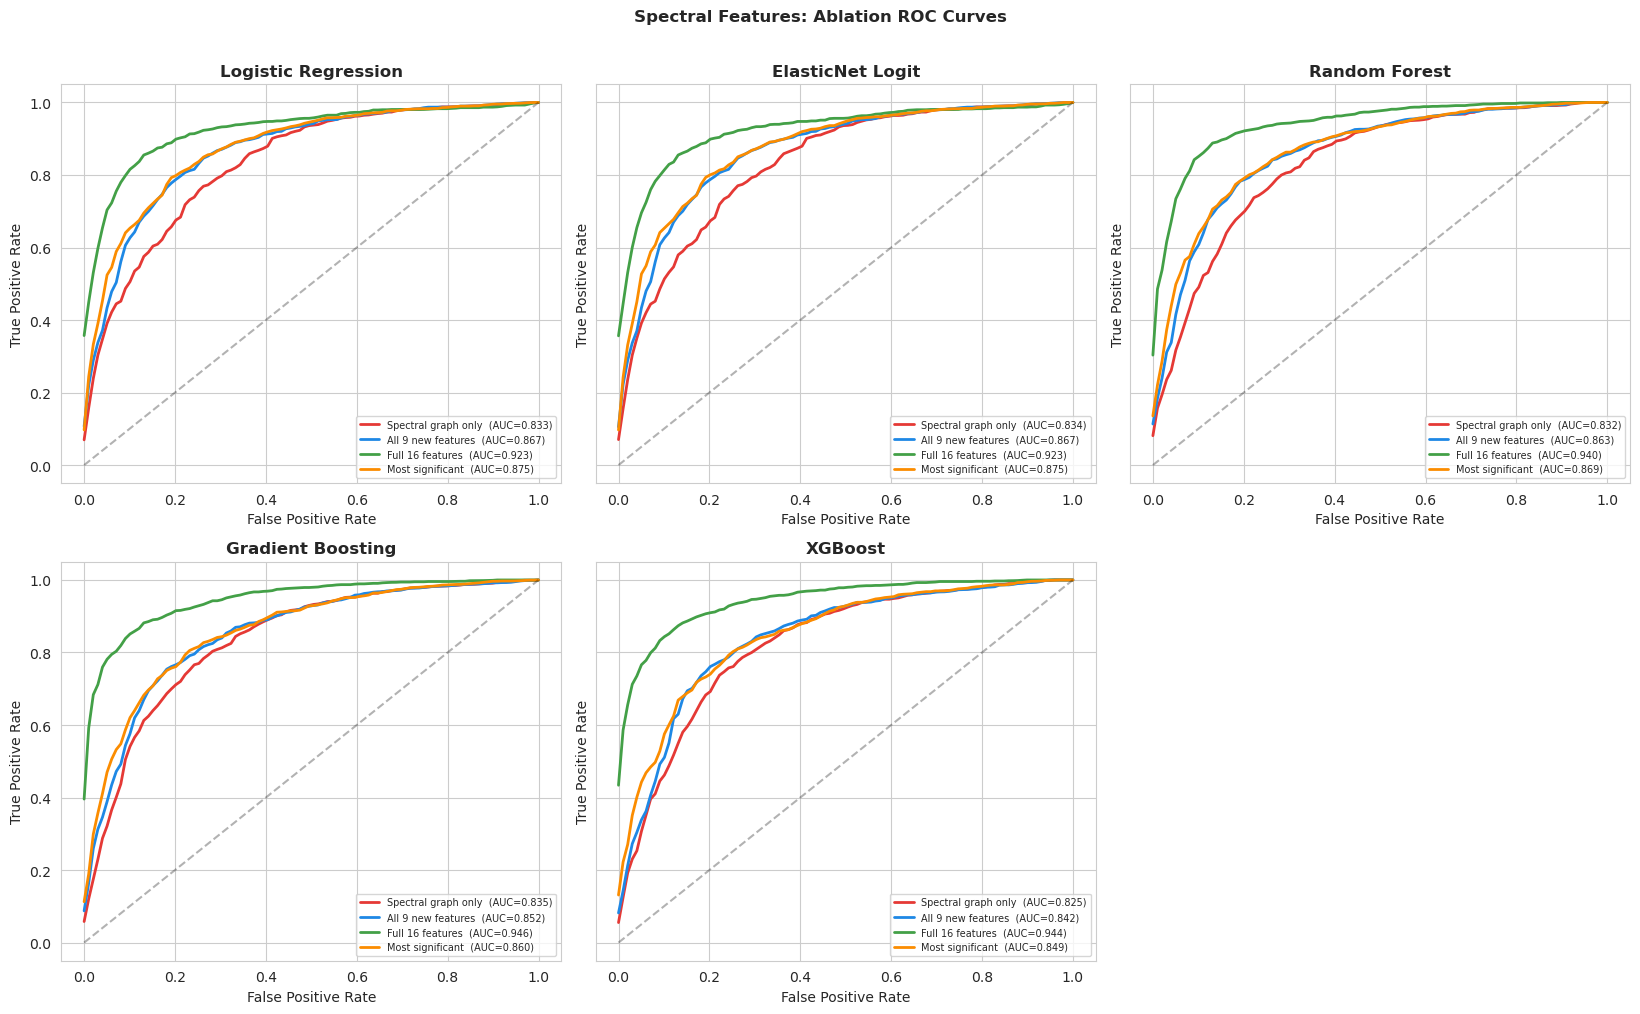

In [19]:
fig = plot_ablation_roc_curves(
    X_sc_all, y_all,
    classifiers=classifiers,
    ablation_sets={k: ('', [feat_to_idx[f] for f in v])
                   for k, v in ABLATION_SPECTRAL.items()},
    dataset_name='Spectral Features',
    random_seed=RANDOM_SEED,
)
plt.savefig(os.path.join(OUTPUT_DIR, 'spectral_ablation_roc.png'), dpi=150, bbox_inches='tight')
plt.show()


### Feature-Level ROC — New Features


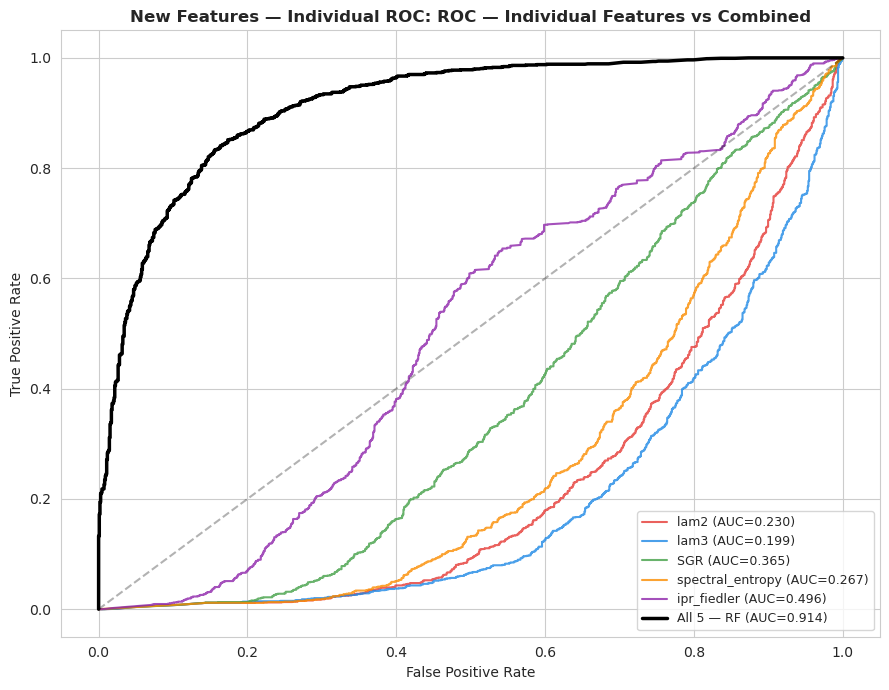

In [20]:
idx_new = [feat_to_idx[f] for f in ALL_NEW_FEATURES]
fig = plot_roc_curves(
    X_sc_all[:, idx_new], y_all,
    geo_features=ALL_NEW_FEATURES,
    dataset_name='New Features — Individual ROC',
    random_seed=RANDOM_SEED,
)
plt.savefig(os.path.join(OUTPUT_DIR, 'spectral_roc_individual.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## SHAP

SHAP beeswarm on (a) all 9 new features, (b) the full 16-feature pipeline.
Red = high feature value, blue = low. Right of centre = increases hallucination score.


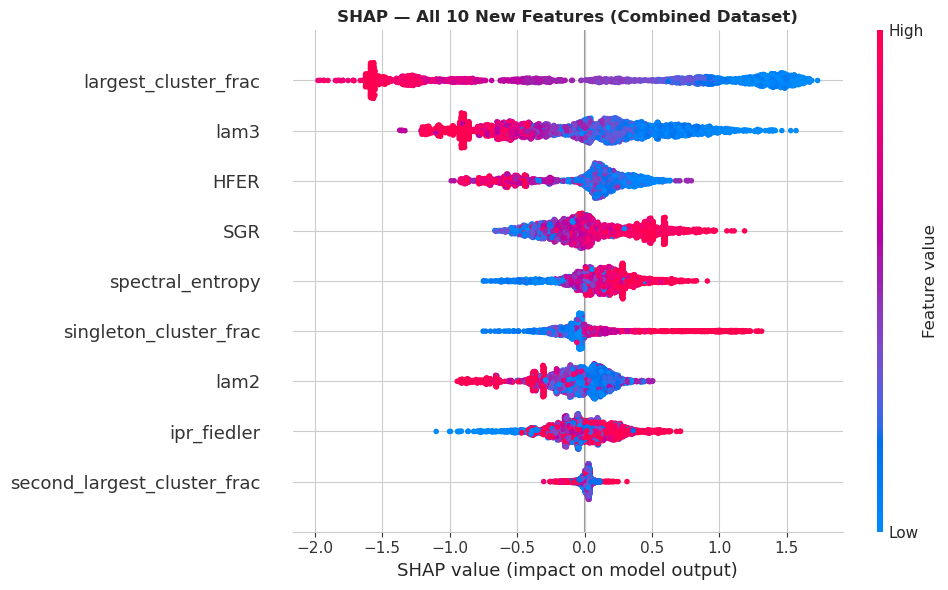

In [21]:
fig = plot_shap_beeswarm(
    X_sc_all[:, idx_new], y_all,
    geo_features=ALL_NEW_FEATURES,
    title='SHAP — All 10 New Features (Combined Dataset)',
    figsize=(10, 6),
)
plt.savefig(os.path.join(OUTPUT_DIR, 'spectral_shap_new.png'), dpi=150, bbox_inches='tight')
plt.show()


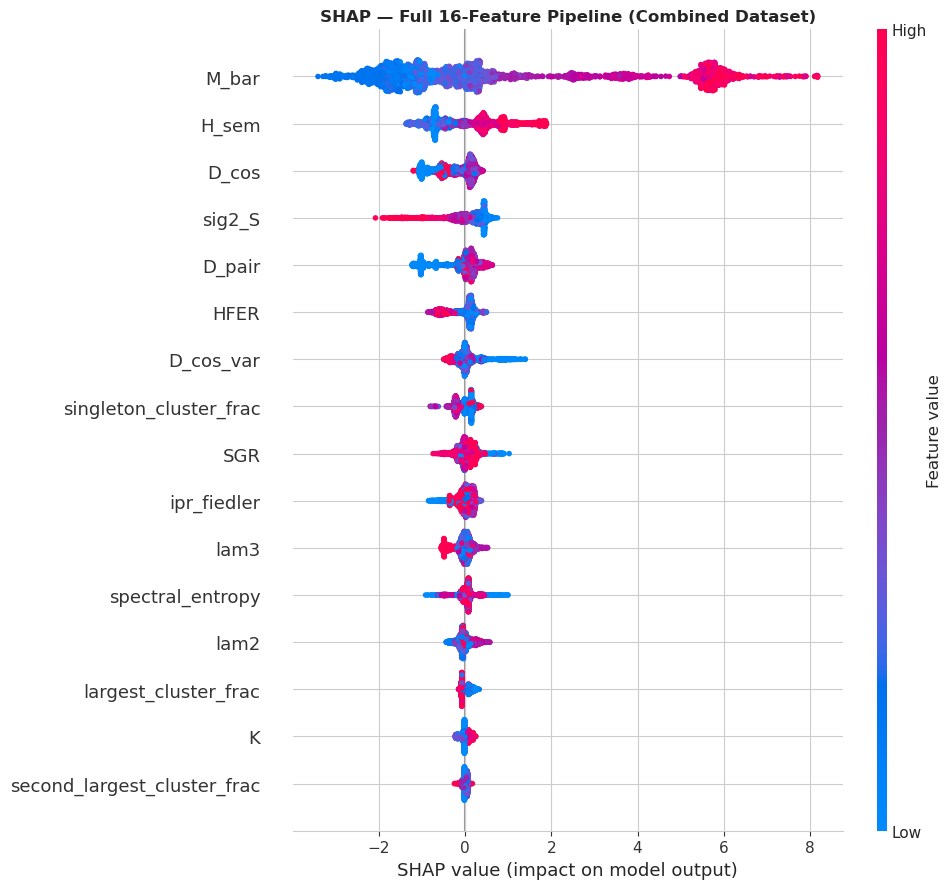

In [24]:
fig = plot_shap_beeswarm(
    X_sc_all, y_all,
    geo_features=ALL_FEATURES,
    title='SHAP — Full 16-Feature Pipeline (Combined Dataset)',
    figsize=(10, 9),
)
plt.savefig(os.path.join(OUTPUT_DIR, 'spectral_shap_full19.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## Summary


In [27]:
print('=' * 70)
print('SPECTRAL GRAPH FEATURES — RESULTS SUMMARY')
print('=' * 70)
print(f'  Questions       : {len(feat_df):,}')
print(f'  Features        : {len(ALL_FEATURES)} total '
      f'(7 baseline + 6 spectral + 3 extended cluster)')
print(f'  Hallu rate      : {feat_df["label"].mean()*100:.1f}%')
print()
print('  KS-significant features:',
       df_ks[df_ks['Significant']]['Feature'].tolist())
# print()
# print(f'  Permutation λ₂  : Δ={delta_lam2:.4f}  p={pval_lam2:.6f}')
# print(f'  Permutation sing: Δ={delta_sing:.4f}  p={pval_sing:.6f}')
print()
for lbl, (boot, lo, hi) in boot_results.items():
    print(f'  Bootstrap {lbl[:20]:20s}: AUC={boot.mean():.4f}  [{lo:.4f}, {hi:.4f}]')
print()
best = df_abl.loc[df_abl['AUC_mean'].idxmax()]
print(f'  Best config: {best["Classifier"]} / {best["Variant"]}')
print(f'               AUC = {best["AUC_mean"]:.4f}')
print('=' * 70)


SPECTRAL GRAPH FEATURES — RESULTS SUMMARY
  Questions       : 2,500
  Features        : 16 total (7 baseline + 6 spectral + 3 extended cluster)
  Hallu rate      : 55.8%

  KS-significant features: ['lam2', 'lam3', 'SGR', 'spectral_entropy', 'ipr_fiedler', 'HFER', 'largest_cluster_frac', 'second_largest_cluster_frac', 'singleton_cluster_frac']

  Bootstrap Spectral graph only : AUC=0.8282  [0.8061, 0.8505]

  Best config: Gradient Boosting / Full 16 features
               AUC = 0.9457
